# Element Classification Dataset Preview

This notebook demonstrates the `ClassificationDataGenerator` which creates datasets for multi-label classification of XRF spectra.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

# Ensure project root is in sys.path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data.classification.generator import ClassificationDataGenerator
from src.data.common.base_generator import GeneratorConfig, preview_dataset

## Generate Samples
Generating 50 synthetic spectra with random combinations of 1 to 5 elements.

In [2]:
gen = ClassificationDataGenerator()
config = GeneratorConfig.Presets.balanced()
config.summary()

X, y = gen.generate_dataset(num_samples=50, min_elements=1, max_elements=5, config=config)

print(f"X shape: {X.shape} (samples, energy_bins)")
print(f"y shape: {y.shape} (samples, elements)")

----------------------------------------
      XRF Generator Configuration       
----------------------------------------
s_counts_range      : (30000, 80000)
n_counts_range      : (1000, 5000)
b_counts_range      : (3000, 3000)
c_counts_range      : (3000, 3000)
escape_prob         : 1.0
sum_peaks_prob      : 1.0
decal_prob          : 0.0
kvp_range           : (30.0, 30.0)
angle_range         : (46.0, 46.0)
mas_range           : (9.0, 9.0)
target_materials    : ['Mo']
filters             : [('Be', 0.127), ('Air', 10.0)]
----------------------------------------


Generating Classification Dataset: 100%|██████████| 50/50 [00:30<00:00,  1.63it/s]

X shape: (50, 600) (samples, energy_bins)
y shape: (50, 41) (samples, elements)


## Dataset Analysis
Let's look at the label distribution across our 50 samples.

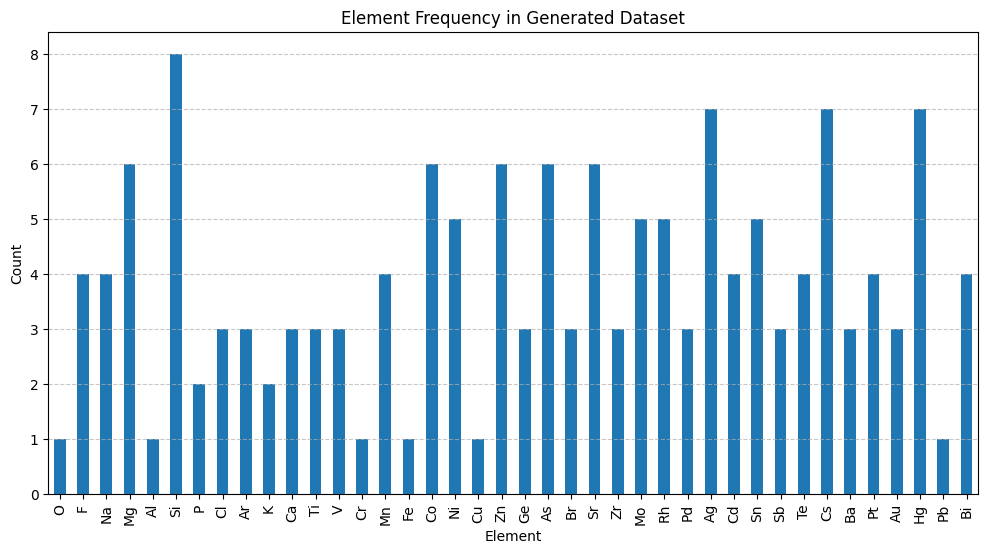

In [3]:
element_counts = y.sum()
element_counts = element_counts[element_counts > 0]

plt.figure(figsize=(12, 6))
element_counts.plot(kind='bar')
plt.title("Element Frequency in Generated Dataset")
plt.ylabel("Count")
plt.xlabel("Element")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Preview Spectra
Plotting a few samples with their multi-label ground truth.

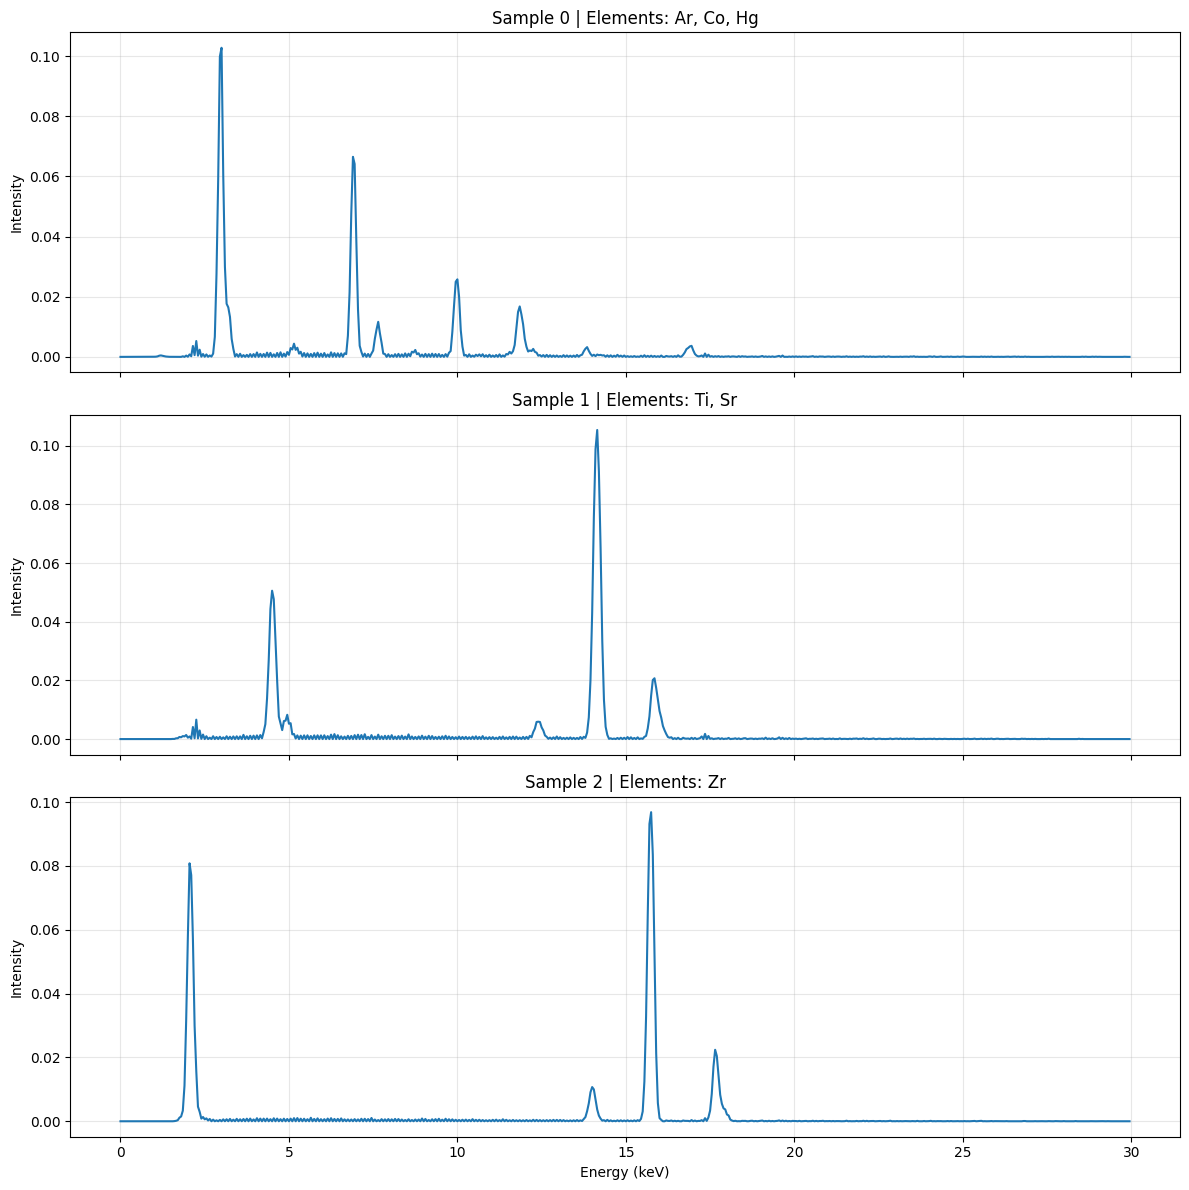

In [4]:
num_previews = 3
energies = np.arange(0, 30, 0.05)  # 600 bins for 30keV / 0.05dk

fig, axes = plt.subplots(num_previews, 1, figsize=(12, 4 * num_previews), sharex=True)

for i in range(num_previews):
    ax = axes[i]
    ax.plot(energies, X[i])
    
    # Get active elements
    active_elements = y.columns[y.iloc[i] == 1].tolist()
    
    ax.set_title(f"Sample {i} | Elements: {', '.join(active_elements)}")
    ax.set_ylabel("Intensity")
    ax.grid(alpha=0.3)

plt.xlabel("Energy (keV)")
plt.tight_layout()
plt.show()